# WikiText-2 fixed split-count comparison

Train matched tiny SelfAttention and PRA models with paired seeds 1, 7, 21, 42, and 87 at total split counts 2 and 5. The final split is the prediction tail, so the runs expose one and four references respectively.

In [1]:
from pathlib import Path
import sys

repo = Path.cwd()
if repo.name == 'nb':
    repo = repo.parent
sys.path.insert(0, str(repo / 'src'))
sys.path.insert(0, str(repo / 'nb'))
sys.path.insert(0, str(repo))

import pra_notebook_utils as pnu

EXPERIMENTS = [
    'td_sa_tiny_wikitext2_refs_split2_smoke',
    'td_sa_tiny_wikitext2_refs_split5_smoke',
    'td_pra_tiny_wikitext2_refs_split2_smoke',
    'td_pra_tiny_wikitext2_refs_split5_smoke',
]
SEEDS = [1, 7, 21, 42, 87]
WRITE_IMAGES_TO_DISK = False

In [2]:
runtime = pnu.configure_notebook(repo=repo, seed=SEEDS[0], write_images_to_disk=WRITE_IMAGES_TO_DISK)
runtime.as_dict()

{'repo': 'D:\\git\\rd\\pdattention',
 'seed': 1,
 'device': 'cuda',
 'write_images_to_disk': False,
 'python': '3.10.11',
 'torch_version': '2.12.1+cu126',
 'torch_cuda': '12.6',
 'cuda_available': True,
 'gpu': 'NVIDIA GeForce GTX 950M',
 'compute_capability': (5, 0)}

In [3]:
_, _, tokenizer_datamodule = pnu.prepare_wikitext_reference_experiment(
    runtime, EXPERIMENTS[0]
)
shared_tokenizer = tokenizer_datamodule.tokenizer
{'vocab_size': shared_tokenizer.vocab_size, 'shared_across_runs': True}

{'vocab_size': 1309, 'shared_across_runs': True}

In [4]:
def run_split_experiment(experiment_name, seed):
    run_runtime = pnu.configure_notebook(
        repo=repo, seed=seed, write_images_to_disk=WRITE_IMAGES_TO_DISK
    )
    result = pnu.train_wikitext_reference_experiment(
        run_runtime, experiment_name, tokenizer=shared_tokenizer
    )
    pnu.evaluate_reference_conditions(result)
    split_count = result['loader_summary']['split_count']
    report_path = pnu.generate_html_report(
        result,
        runtime=run_runtime,
        dataset_details=result['loader_summary'],
        model_name=result['model_name'],
        qualifiers=(f'split{split_count}', f'seed{seed}', f'steps{result["global_step"]}', f'seq{result["policy"].max_seq_len}'),
    )
    return result, report_path

In [5]:
runs = [
    run_split_experiment(name, seed)
    for name in EXPERIMENTS
    for seed in SEEDS
]
results = [run[0] for run in runs]
report_paths = [run[1] for run in runs]

[config] TrainConfig(experiment_name='td_sa_tiny_wikitext2_references_v2_td_sa_tiny_wikitext2_refs_split2_smoke_scratch_seed1_steps8_seq128', output_dir='D:\\git\\rd\\pdattention\\out\\notebook_wikitext_refs', seed=1, device='cuda', dtype='float32', epochs=1, max_steps=8, batch_size=2, grad_accum_steps=1, learning_rate=0.0003, weight_decay=0.0, warmup_steps=0, max_grad_norm=1.0, eval_every_steps=8, save_every_steps=8, log_every_steps=1, num_workers=0, pin_memory=False, persistent_workers=False, resume_from=None, use_tensorboard=False, save_metric_plots=False, use_wandb=False, wandb_project='transformer-experiments', use_clearml=False, clearml_project='Transformer Experiments', mixed_precision=False, early_stopping_patience=None, dataset_stage='wikitext2_references_v2', data_dir='D:\\git\\rd\\pdattention\\data\\generated\\wikitext2_references_v2_split2_seed1729_examples32', max_examples=32, max_seq_len=128, shuffle=True, resolver_config=ResolverServiceConfig(type='in_memory', options={}

epoch 1/1:   0%|          | 0/13 [00:00<?, ?it/s]

epoch 1/1:   0%|          | 0/13 [00:00<?, ?it/s, step=1, loss=7.44, lr=0.0003, ex/s=6.56, tok/s=361]

epoch 1/1:   8%|▊         | 1/13 [00:00<00:03,  3.24it/s, step=1, loss=7.44, lr=0.0003, ex/s=6.56, tok/s=361]

epoch 1/1:   8%|▊         | 1/13 [00:00<00:03,  3.24it/s, step=2, loss=7.19, lr=0.0003, ex/s=22.4, tok/s=1.25e+3]

...

epoch 1/1:  54%|█████▍    | 7/13 [00:02<00:01,  4.47it/s, step=8, loss=7.34, lr=0.0003, ex/s=8.87, tok/s=545, val=7.24]

epoch 1/1:  54%|█████▍    | 7/13 [00:02<00:02,  2.47it/s, step=8, loss=7.34, lr=0.0003, ex/s=8.87, tok/s=545, val=7.24]

[train_epoch step=1] train_loss=7.2846 perplexity=1457.6053 learning_rate=0.0003 grad_norm=3.2424 examples_per_second=5.6421 tokens_per_second=414.3448 gpu_memory_allocated=949.5588 train_batch_duration_seconds=0.2266 retrieval_reference_hit_at_1=0.4531 retrieval_reference_hit_at_k=0.4531 retrieval_reference_recall_at_k=0.4531 retrieval_reference_precision_at_k=0.4531 retrieval_reference_f1_at_k=0.4531 retrieval_reference_mrr=0.4531 retrieval_reference_ndcg=0.4531 retrieval_reference_selected_count=1.0000 memory_available_reference_count=4.0000 memory_available_chunk_count=4.0000 cache_reference_token_count=182.5000 retrieval_selected_reference_count=1.0000 retrieval_selected_chunk_count=1.0000 memory_selected_token_count=46.1562 memory_selected_reference_fraction=0.2500 memory_selected_chunk_fraction=0.2500 memory_selected_token_fraction=0.2515 retrieval_routing_score_mean=0.0444 retrieval_routing_score_max=0.0444 retrieval_zero_chunk_fraction=0.0000 memory_retrieved_chunk_attended_fr

[test step=8] test_loss=7.0630 retrieval_reference_hit_at_1=0.3125 retrieval_reference_hit_at_k=0.3125 retrieval_reference_recall_at_k=0.3125 retrieval_reference_precision_at_k=0.3125 retrieval_reference_f1_at_k=0.3125 retrieval_reference_mrr=0.3125 retrieval_reference_ndcg=0.3125 retrieval_reference_selected_count=1.0000 memory_available_reference_count=4.0000 memory_available_chunk_count=4.0000 cache_reference_token_count=174.5000 retrieval_selected_reference_count=1.0000 retrieval_selected_chunk_count=1.0000 memory_selected_token_count=44.4375 memory_selected_reference_fraction=0.2500 memory_selected_chunk_fraction=0.2500 memory_selected_token_fraction=0.2547 retrieval_routing_score_mean=0.0377 retrieval_routing_score_max=0.0377 retrieval_zero_chunk_fraction=0.0000 memory_retrieved_chunk_attended_fraction=1.0000 cache_recursive_expansion_depth=0.0000 cache_recursive_reference_budget_fraction=0.0625 cache_recursive_token_budget_fraction=0.0245 layer_0_reference_hit_at_1=0.5000 layer_

wrote HTML report: D:\git\rd\pdattention\out\reports\td_pra_tiny_wikitext2_references_v2_split5_seed87_steps8_seq128\index.html


In [6]:
split_summaries = [pnu.summarize_workload(result) for result in results]
split_summaries

[{'dataset_stage': 'wikitext2_references_v2',
  'size': 32,
  'parameters': 3862528,
  'epochs': 1,
  'optimizer_steps': 8,
  'batch_steps': 8,
  'train_loss': 7.2593623995780945,
  'validation_loss': 7.2444526354471845,
  'test_loss': 7.132812261581421,
  'test_perplexity': 1252.3940788285702,
  'test_token_accuracy': None,
  'test_answer_accuracy': 0.0,
  'test_reference_accuracy': 0.0,
  'test_reference_top1_accuracy': 0.0,
  'test_reference_topk_accuracy': 0.0,
  'test_reference_mrr': 0.0,
  'split_count': 2,
  'reference_count': 1,
  'initial_validation_loss': 7.388993581136067,
  'initial_reference_top1_accuracy': 0.0,
  'initial_reference_topk_accuracy': 0.0,
  'initial_reference_mrr': 0.0,
  'wall_clock_seconds': 1.1601378000341356,
  'train_duration_seconds': 0.715078899927903,
  'validation_duration_seconds': 0.03342079999856651,
  'test_duration_seconds': 0.04209800000535324,
  'processed_tokens': 912,
  'sequences_seen': 16,
  'optimizer_steps_per_second': 11.18757664476827

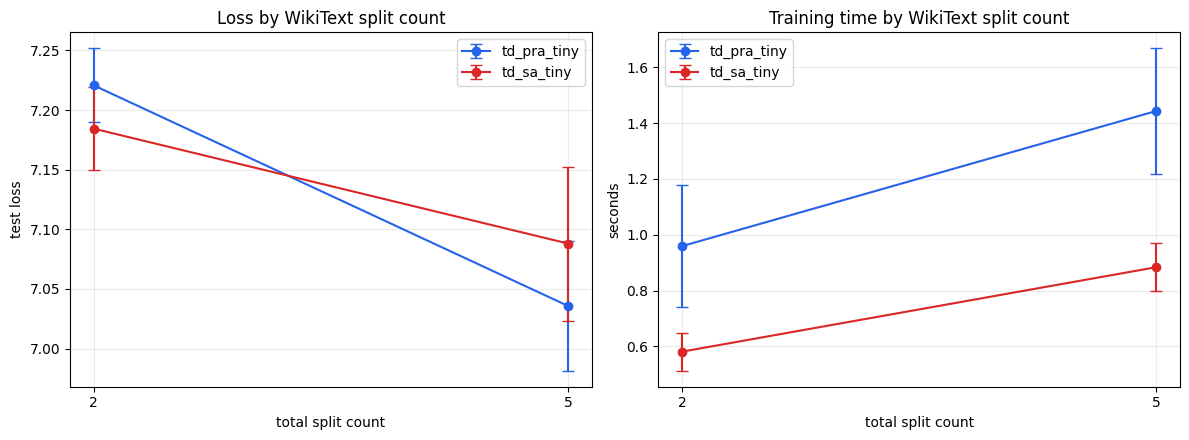

wrote split-count HTML report: D:\git\rd\pdattention\out\reports\wikitext2_split_count_comparison\index.html


WindowsPath('D:/git/rd/pdattention/out/reports/wikitext2_split_count_comparison/index.html')

In [7]:
comparison_report = pnu.generate_split_count_html_report(
    results, report_paths, runtime=runtime
)
comparison_report